In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# load general packages
import numpy as np
import matplotlib.pyplot as plt
import time

# load modules related to this exercise
from model_dc import model_dc

# Exercise 5: Solving discrete-continuous choice models
Consider the discrete-continuous choice model of consumption-saving and retirement.

The *value function* is given as
$$\begin{align*}
v_{t}(m_{t},z_t,\eta_t^0,\eta_t^1) & = & \max_{z_{t+1}\in \mathcal{Z}(z_t)}\left\{\mathcal{V}_t(m_t,z_{t+1})+\sigma_{\eta}\eta_t^{z_{t+1}}\right\} \\
\mathcal{Z}(z_t) &= &\begin{cases}
\{0,1\} & \text{if} & z_t=0 \\
\{1\} & \text{if} & z_t = 1
\end{cases}
\end{align*}$$
, where $\mathcal{Z}(z_t)$ is the *choice set* of an agent with state $z_t$.


The *choice-specific value functions* are given by
$$\begin{align*}
 \mathcal{V}_t(m_t,z_{t+1}) & = & \max_{c_t} \frac{c_{t}^{1-\rho}}{1-\rho}-\alpha \mathbb{1}_{z_{t+1}=0} +\beta\mathbb{E}_{t}\left[v_{t+1}(\bullet_{t+1})\right] \\
  & \text{s.t.}\\
m_{t+1} & = & R(m_{t}-c_{t})+W \xi_{t+1} \mathbb{1}_{z_{t+1}=0}\\
c_t & \leq & m_t\\
\xi_{t+1} & \sim & \exp( \mathcal{N}(-0.5 \sigma_{\xi}^{2} ,\sigma_{\xi}^{2}))\\
\eta_t^0,\eta_t^1 & \sim & \text{Extreme Value Type 1}
\end{align*}$$
The completed exercise illustrates the EGM step, choice-specific value functions, the upper envelope, and the effect of taste shocks on retirement incentives.

## State convention and baseline parameters

The code uses `z_plus=0` for **working next period** and `z_plus=1` for **retired next period**. Retirement is absorbing. Key parameters are:

| Concept | Code | Baseline | Interpretation |
|---|---:|---:|---|
| Discount factor | `beta` | 0.96 | Patience and intertemporal allocation. |
| Relative risk aversion | `rho` | 2.0 | Curvature of consumption utility. |
| Cost of working | `alpha` | 0.75 | Utility cost paid when choosing work. |
| Income risk | `sigma_xi` | 0.0 | Dispersion of labor income shocks. |
| Taste-shock scale | `sigma_eta` | 0.20 | Smooths the discrete work/retirement decision. |

Change parameters after `model.setup()` and before `model.create_grids()` or `model.solve()`. The taste-shock scale affects the logsum and choice probabilities directly; it does not require new quadrature nodes.


## 1. Ensure that you understand all functions in $\texttt{model\_dc.py}$

## 2. Understand the economic role of the functions in `egm_dc.py`. Treat the upper-envelope scan as a supplied numerical routine on a first pass.


## 3. Review the standard EGM calculations in `egm_dc.EGM`.



## 4. Solve the one-dimensional model and inspect the choice-specific policies

In [3]:
model = model_dc()
model.setup()
model.create_grids()
model.solve()

par = model.par
sol = model.sol

In [4]:
# define figures

# retired
def figure(par,sol,z):
    if z == 1:
        print(f'Retired in t+1')
        ts = [par.T, par.T-1, par.T-2, par.T-3, 1]
    elif z ==0:
        print(f'Working in t+1')
        ts = [par.T, par.T-1, par.T-2, par.T-3, par.T-4]
    fig = plt.figure(figsize=(15,5))
    ax = fig.add_subplot(1,2,1)
    for i in ts:
        ax.scatter(sol.m[i-1,z,:],sol.c[i-1,z,:], label=f't = {i}')
    ax.set_xlabel(f"$m_t$")
    ax.set_ylabel(f"$c(m_t,z_{{t+1}} = {z})$")
    ax.set_xlim([0, 5])
    ax.set_ylim([0,3])
    ax.set_title(f'Consumption function')
    plt.legend()

    ax_right = fig.add_subplot(1,2,2)
    for i in ts:
        ax_right.scatter(sol.m[i-1,z,:],sol.v[i-1,z,:], label=f't = {i}')
    ax_right.set_xlabel(f"$m_t$")
    ax_right.set_ylabel(f"$v(m_t,z_{{t+1}} = {z})$")
    ax_right.set_xlim([0, 5])
    ax_right.set_ylim([-20,0])
    ax_right.set_title(f'Value function')
    plt.legend()
    plt.show()

sigma_eta = 0.0
Working in t+1


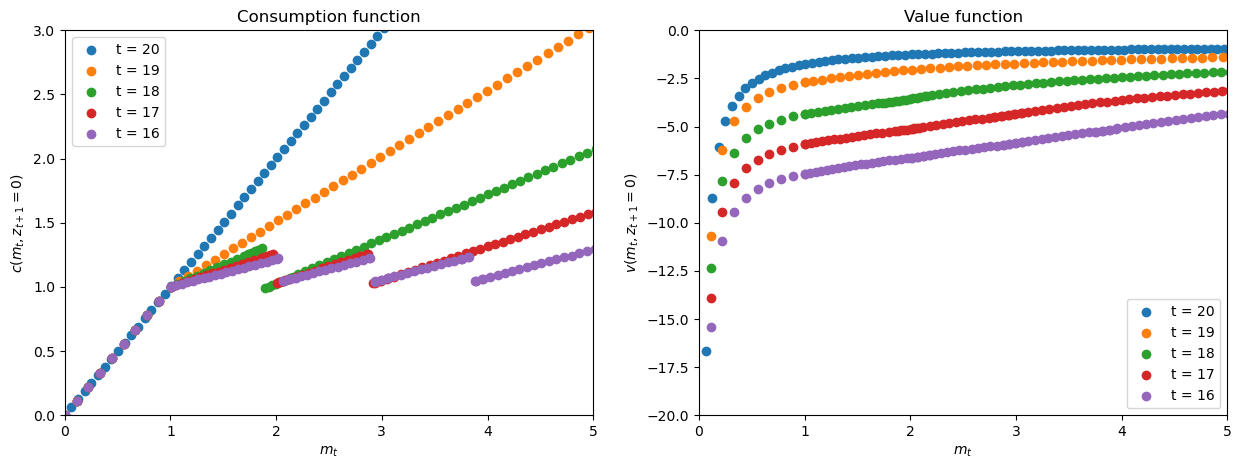

sigma_eta = 0.0
Retired in t+1


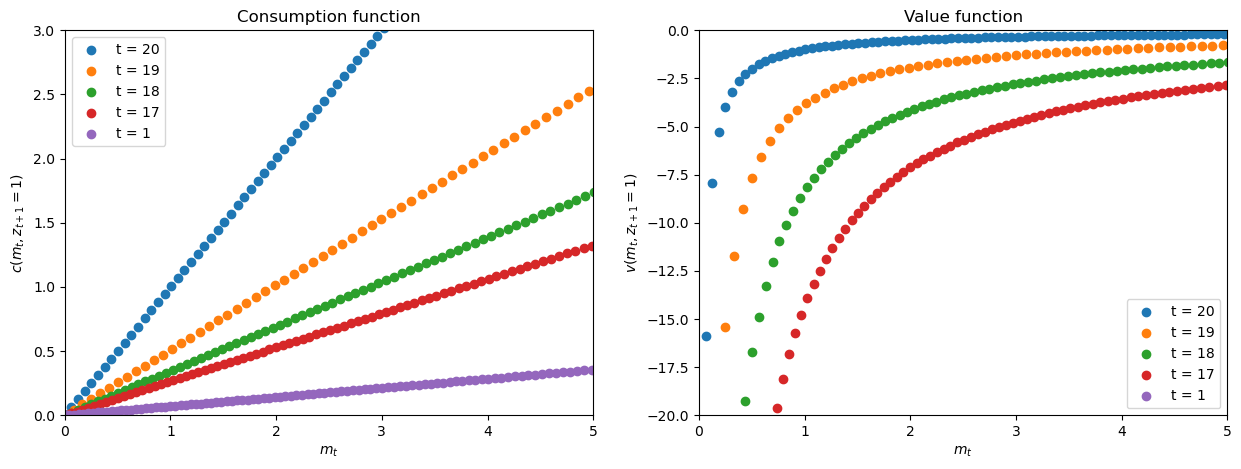

sigma_eta = 0.01
Working in t+1


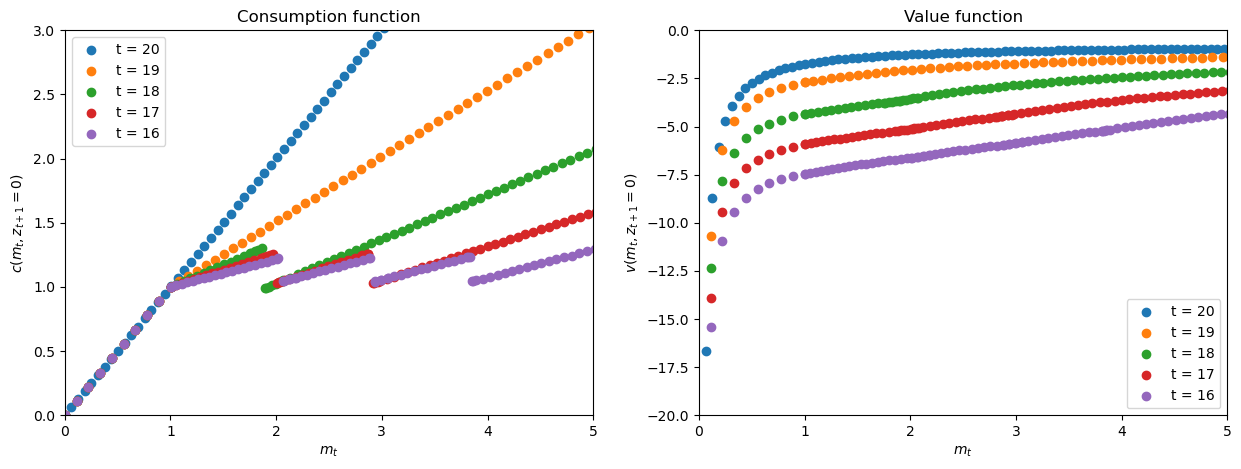

sigma_eta = 0.01
Retired in t+1


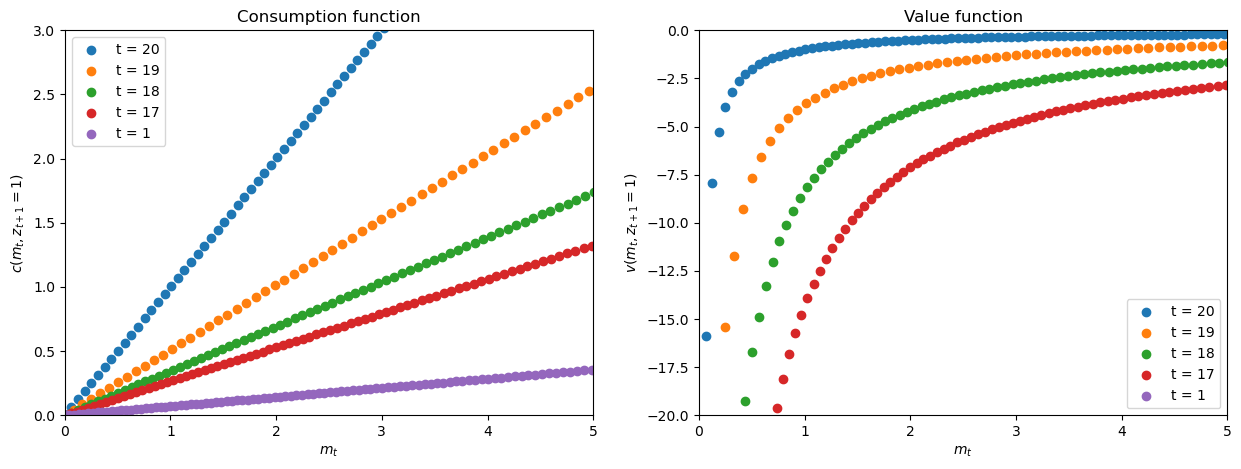

sigma_eta = 0.05
Working in t+1


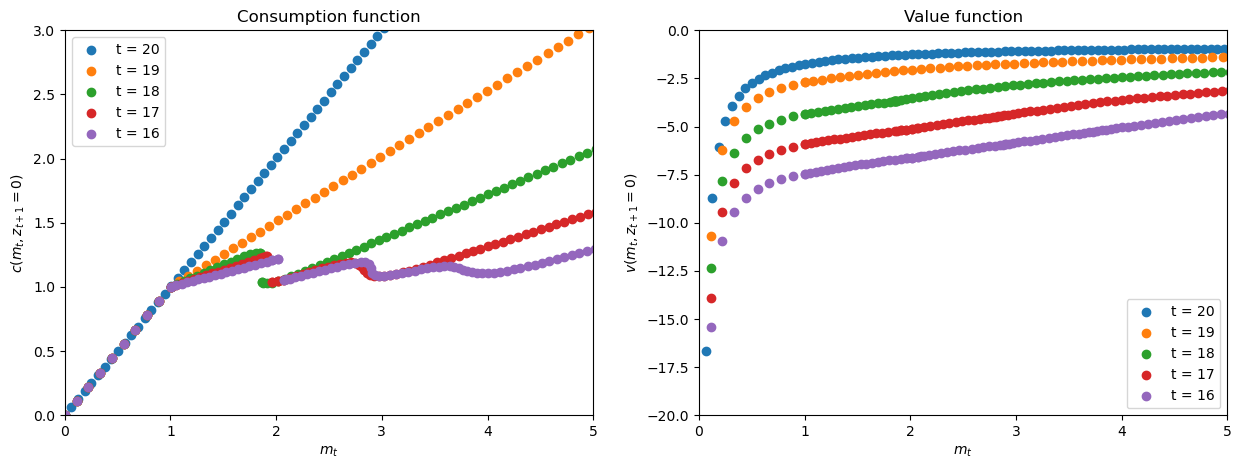

sigma_eta = 0.05
Retired in t+1


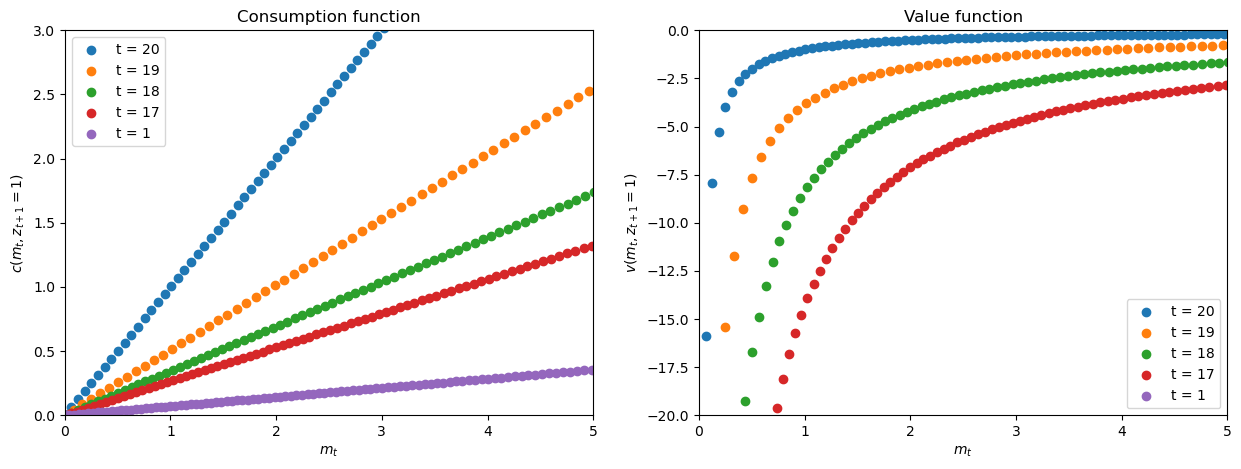

sigma_eta = 0.1
Working in t+1


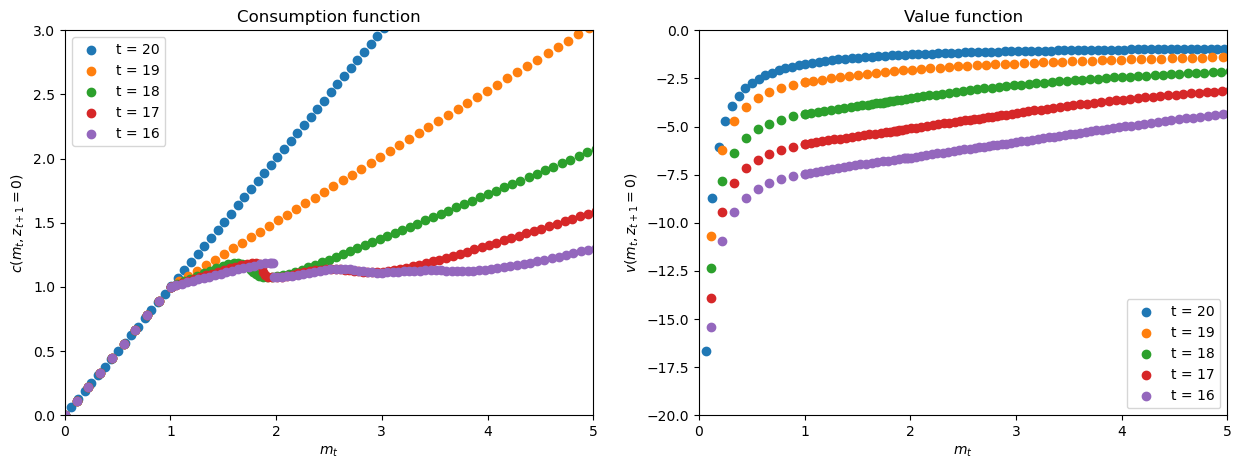

sigma_eta = 0.1
Retired in t+1


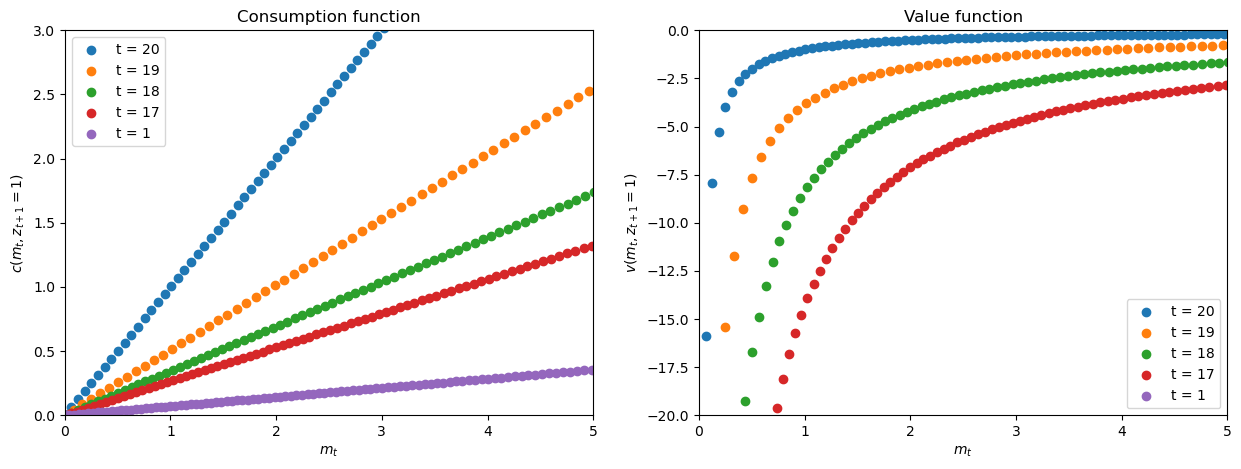

sigma_eta = 0.2
Working in t+1


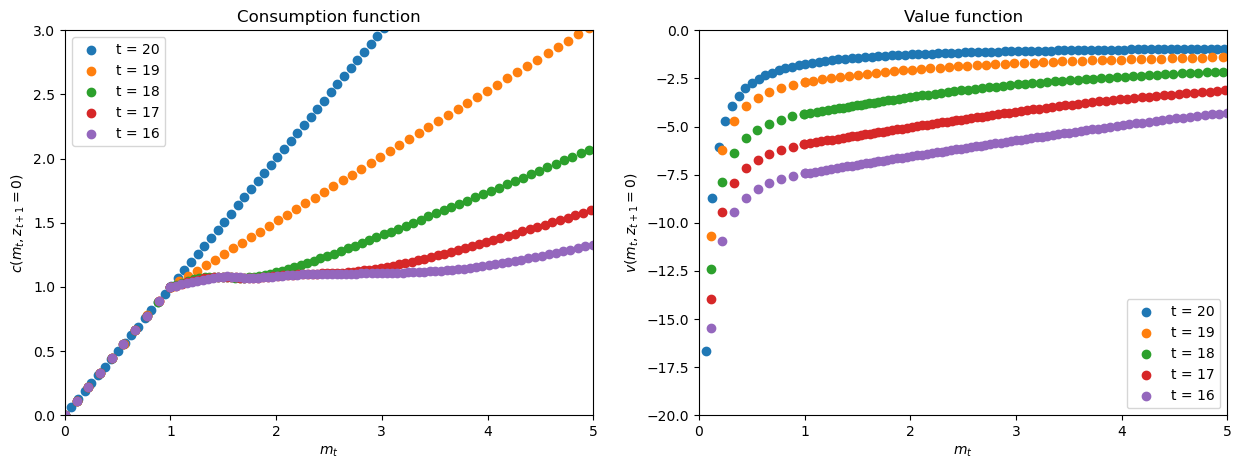

sigma_eta = 0.2
Retired in t+1


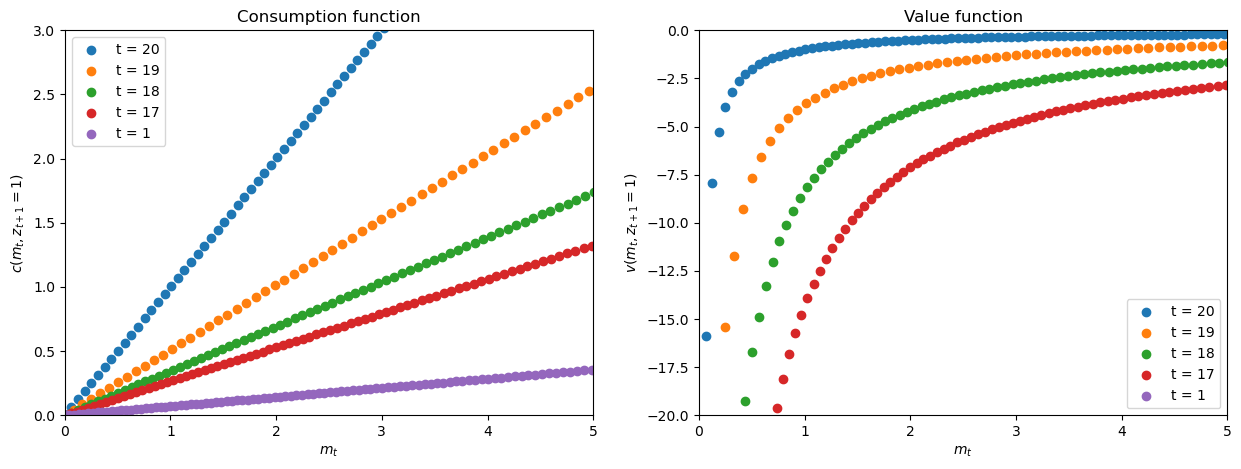

In [5]:
# Print figures for different sigma
sigma_eta_vec = [0.0,0.01,0.05,0.1,0.2]

for i,val in enumerate(sigma_eta_vec):
    model.setup()
    model.par.sigma_eta = val
    model.create_grids()
    model.solve()
    print(f'sigma_eta = {model.par.sigma_eta}')
    figure(model.par,model.sol,0)
    print(f'sigma_eta = {model.par.sigma_eta}')
    figure(model.par,model.sol,1)

## 5. Economic diagnostics: thresholds and taste-shock smoothing

Without taste shocks (`sigma_eta=0`), the choice-specific value functions are combined with a max operator. Their crossing produces a sharp retirement threshold and may produce a discontinuity in consumption. With positive taste shocks, logsum replaces max and the retirement decision becomes probabilistic.

Before running the cell:

1. Predict how increasing `sigma_eta` changes the retirement probability around the threshold.
2. Predict how increasing `alpha`, the utility cost of working, shifts retirement probabilities.
3. Identify where the value difference crosses zero and relate it to the retirement-probability figure.


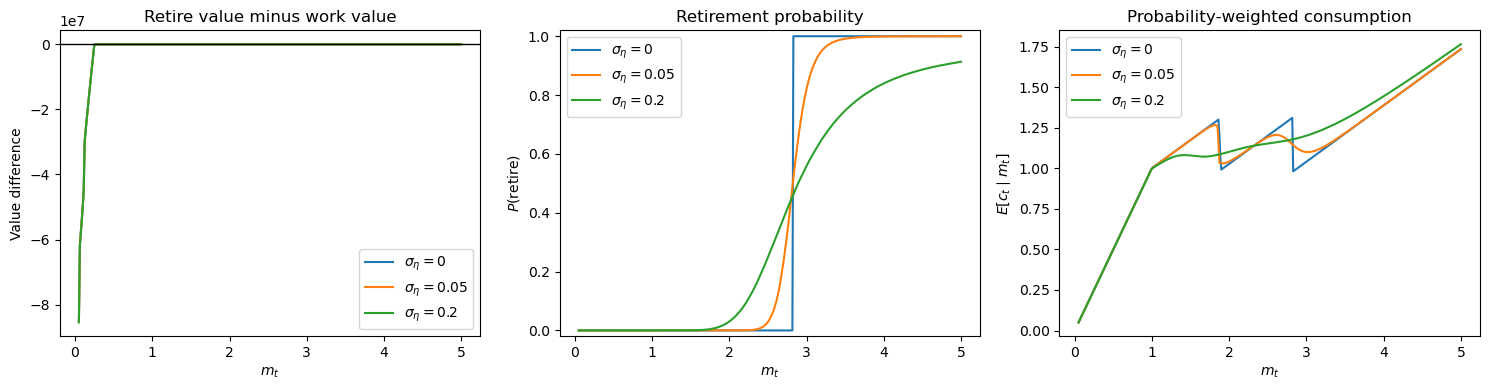

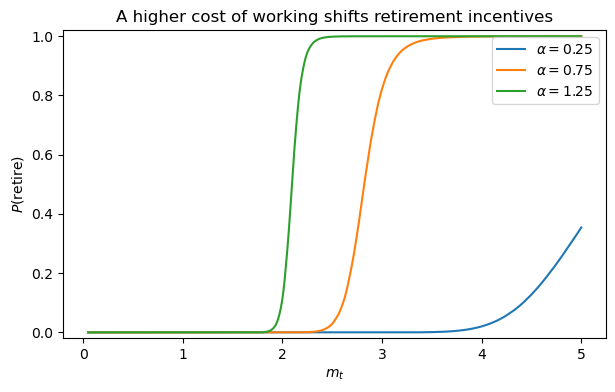

In [6]:
def dc_diagnostics(sigma_eta=0.2, alpha=0.75, t=None):
    """Solve the retirement model and return policies on a common cash grid."""
    case = model_dc()
    case.setup()
    case.par.sigma_eta = sigma_eta
    case.par.alpha = alpha
    case.create_grids()
    case.solve()

    if t is None:
        t = case.par.T - 3
    m = np.linspace(0.05, 5.0, 400)
    v_work = np.interp(m, case.sol.m[t, 0], case.sol.v[t, 0])
    v_retire = np.interp(m, case.sol.m[t, 1], case.sol.v[t, 1])
    c_work = np.interp(m, case.sol.m[t, 0], case.sol.c[t, 0])
    c_retire = np.interp(m, case.sol.m[t, 1], case.sol.c[t, 1])

    if sigma_eta > 1e-10:
        vmax = np.maximum(v_work, v_retire)
        exp_work = np.exp((v_work - vmax) / sigma_eta)
        exp_retire = np.exp((v_retire - vmax) / sigma_eta)
        prob_retire = exp_retire / (exp_work + exp_retire)
    else:
        prob_retire = (v_retire >= v_work).astype(float)

    expected_c = (1 - prob_retire) * c_work + prob_retire * c_retire
    return m, v_retire - v_work, prob_retire, expected_c


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for sigma_eta in [0.0, 0.05, 0.20]:
    m, value_difference, probability, expected_c = dc_diagnostics(sigma_eta=sigma_eta)
    label = rf"$\sigma_\eta={sigma_eta:g}$"
    axes[0].plot(m, value_difference, label=label)
    axes[1].plot(m, probability, label=label)
    axes[2].plot(m, expected_c, label=label)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(title="Retire value minus work value", xlabel=r"$m_t$", ylabel="Value difference")
axes[1].set(title="Retirement probability", xlabel=r"$m_t$", ylabel=r"$P(\mathrm{retire})$", ylim=(-0.02, 1.02))
axes[2].set(title="Probability-weighted consumption", xlabel=r"$m_t$", ylabel=r"$E[c_t\mid m_t]$")
for ax in axes:
    ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for alpha in [0.25, 0.75, 1.25]:
    m, _, probability, _ = dc_diagnostics(sigma_eta=0.05, alpha=alpha)
    ax.plot(m, probability, label=rf"$\alpha={alpha:g}$")
ax.set(title=r"A higher cost of working shifts retirement incentives",
       xlabel=r"$m_t$", ylabel=r"$P(\mathrm{retire})$", ylim=(-0.02, 1.02))
ax.legend()
plt.show()


The optional extension adds permanent income as a continuous state: 
$$\begin{align*}
v_{t}(m_{t},p_t,z_t,\eta_t^0,\eta_t^1) & = & \max_{z_{t+1}\in \mathcal{Z}(z_t)}\left\{\mathcal{V}_t(m_t,z_{t+1})+\sigma_{\eta}\eta_t^{z_{t+1}}\right\} \\
\mathcal{Z}(z_t) &= &\begin{cases}
\{0,1\} & \text{if} & z_t=0 \\
\{1\} & \text{if} & z_t = 1
\end{cases}
\end{align*}$$
and the *choice-specific value functions* are given by
$$\begin{align*}
 \mathcal{V}_t(m_t,p_t,z_{t+1}) & = & \max_{c_t} \frac{c_{t}^{1-\rho}}{1-\rho}-\alpha \mathbb{1}_{z_{t+1}=0} +\beta\mathbb{E}_{t}\left[v_{t+1}(\bullet_{t+1})\right] \\
  & \text{s.t.}\\
p_{t+1} & = &  \begin{cases}
p_t & \text{if} & z_{t+1}=1 \\
\xi_{t+1}p_t & \text{if} & z_{t+1} = 0
\end{cases}  \\
m_{t+1} & = & R(m_{t}-c_{t})+W \mathbb{1}_{z_{t+1}=0} p_{t+1}+ \kappa \mathbb{1}_{z_{t+1}=1} p_{t+1}\\
c_t & \leq & m_t\\
\log(\xi_{t+1}) & \sim & \mathcal{N}(-0.5 \sigma_{\xi}^{2} ,\sigma_{\xi}^{2})\\
\eta_t^0,\eta_t^1 & \sim & \text{Extreme Value Type 1}
\end{align*}$$

## 6. Optional multidimensional extension

Review the permanent-income extension. The extra state requires an outer loop over both the discrete state $z$ and permanent income $p$. The supplied upper-envelope routine maps the irregular endogenous grid back to a common exogenous cash-on-hand grid; this extension is deliberately challenging.


In [7]:
from model_dc_multidim import model_dc_multidim

In [8]:
t0 = time.time()
model = model_dc_multidim()
model.setup()
model.create_grids()
model.solve()
t1 = time.time()
print(f'time: {t1-t0:.4f} seconds')

time: 2.4229 seconds


Working in t+1
p=0.505
Working in t+1
p=1.01
Working in t+1
p=1.52


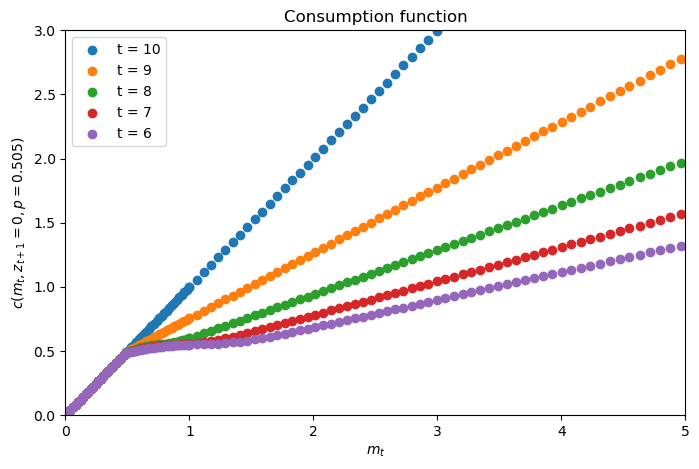

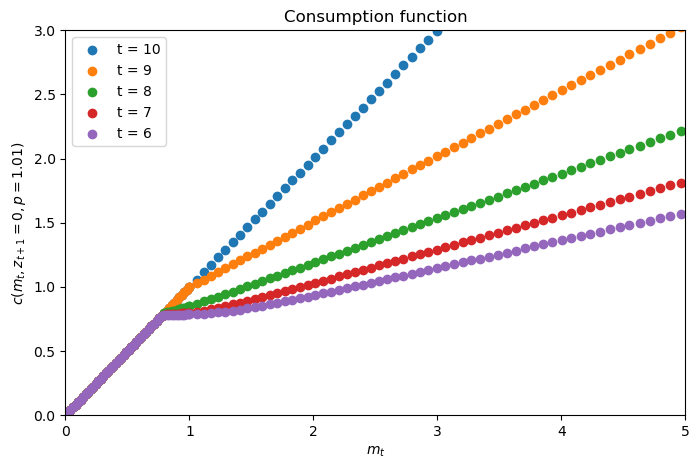

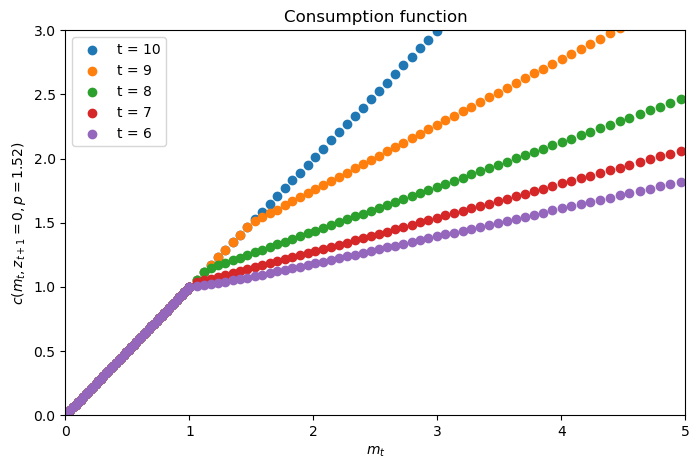

In [9]:
# Figure
def figure_multi_dim(par,sol,z,i_p):
    p = par.grid_p[i_p]
    if z == 0:
        print(f'Working in t+1')
        ts = [par.T, par.T-1, par.T-2, par.T-3, par.T-4]
        print(f'p={p:.3}')
    elif z ==1:
        print(f'Retired in t+1')
        print(f'p={p:.3}')
        ts = [par.T, par.T-1, par.T-2, par.T-3, par.T-4]
    fig = plt.figure(figsize=(8,5))
    ax = fig.add_subplot(1,1,1)
    for i in ts:
        ax.scatter(par.grid_m,sol.c[i-1,z,:,i_p], label=f't = {i}')
    ax.set_xlabel(f"$m_t$")
    ax.set_ylabel(f"$c(m_t,z_{{t+1}} = {z}, p = {p:.3})$")
    ax.set_xlim([0, 5])
    ax.set_ylim([0,3])
    ax.set_title(f'Consumption function')
    ax.legend()

figure_multi_dim(model.par,model.sol,0,25)
figure_multi_dim(model.par,model.sol,0,50)
figure_multi_dim(model.par,model.sol,0,75)